In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
cd "/content/drive/MyDrive/HEMC_model"

/content/drive/MyDrive/HEMC_model


In [2]:
import os
os.environ.setdefault("OBJC_DISABLE_INITIALIZE_FORK_SAFETY", "YES")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import sys
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Le package `hemc` (features EMCCF++, cascade forest, CRF-Viterbi, metriques)
# vit dans src/ a la racine de CE repo -- lancez ce notebook depuis la racine
# du repo (le dossier contenant `src/hemc/`) pour que Path.cwd() la resolve.
PUPIL_ROOT = Path.cwd()
HEMC_SRC = PUPIL_ROOT / "src"
if not (HEMC_SRC / "hemc").exists():
    raise RuntimeError(
        f"Package hemc introuvable sous {HEMC_SRC}. Lancez ce notebook depuis "
        "la racine du repo (le dossier contenant src/hemc/), ou ajustez PUPIL_ROOT."
    )
sys.path.insert(0, str(HEMC_SRC))

from hemc.data import RecordingMeta, group_train_val_test_split, sample_train_val_test_split, iterate_hmr
from hemc.features import extract_emccfpp_features_df, extract_auxiliary_signal_features_df
from hemc.models import (
    CascadeForestClassifier, SequentialCRFDecoder,
    build_transition_matrix, estimate_mean_durations_ms, estimate_transition_counts, viterbi_decode,
)
from hemc.eval import pointwise_report, event_wise_report
from hemc.utils import set_global_seed

CLASSES_4 = ["F", "S", "P", "B"]  # Fixation, Saccade, (smooth) Pursuit, Blink
set_global_seed(42)

# Donnees et cache : sous-dossiers de ce repo. Data/ et cache/ sont gitignores
# (donnees non redistribuables / artefacts regenerables -- cf. README).
DATA_ROOT = PUPIL_ROOT / "Data"
HMR_ROOT = DATA_ROOT / "data_hmr"
RTC_ROOT = DATA_ROOT / "data_RTC"
CACHE_ROOT = PUPIL_ROOT / "cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print(f"HMR_ROOT = {HMR_ROOT} (existe: {HMR_ROOT.exists()})")
print(f"RTC_ROOT = {RTC_ROOT} (existe: {RTC_ROOT.exists()})")

HMR_ROOT = /Users/hanaehammani/HEMC_model/Data/data_hmr (existe: True)
RTC_ROOT = /Users/hanaehammani/HEMC_model/Data/data_RTC (existe: True)


In [3]:
QUICK = True  # True = run rapide (structure/plausibilite) ; False = run complet de reference

RANDOM_STATE = 42
N_ESTIMATORS = 15 if QUICK else 150
MAX_LAYERS = 3 if QUICK else 10
N_JOBS = 1

LIMIT_HMR = 8 if QUICK else None    # 8 recordings = 4 sujets (HMR complet : 13 sujets x 2 yeux = 26 recordings)
LIMIT_RTC = 8 if QUICK else None    # 8 fichiers = 4 participants (RTC complet : 11 participants x 2 sessions = 22 fichiers)

FS_HZ_HMR = 200.0
FS_HZ_RTC = 200.0  # confirme empiriquement : pas temporel median de 0.005s dans timestamp_sec

print(f"QUICK={QUICK} | N_ESTIMATORS={N_ESTIMATORS} | MAX_LAYERS={MAX_LAYERS} | N_JOBS={N_JOBS}")
print(f"LIMIT_HMR={LIMIT_HMR} | LIMIT_RTC={LIMIT_RTC}")


QUICK=True | N_ESTIMATORS=15 | MAX_LAYERS=3 | N_JOBS=1
LIMIT_HMR=8 | LIMIT_RTC=8


In [4]:
RTC_LABEL_MAP = {
    "fixation": "F", "saccade": "S", "microsaccade": "S",
    "smooth_pursuit": "P", "blink": "B",
}

RTC_AUX_RAW_COLUMNS = [
    "pupil diameter left [mm]", "pupil diameter right [mm]",
    "eyelid aperture left [mm]", "eyelid aperture right [mm]",
    "azimuth [deg]", "elevation [deg]", "timestamp_sec",
]


def _gaze_angular_velocity_deg_s(azimuth_deg: np.ndarray, elevation_deg: np.ndarray, timestamp_sec: np.ndarray) -> np.ndarray:
    diffs_t = np.diff(timestamp_sec)
    dt = np.concatenate([[diffs_t[0] if len(diffs_t) else 1.0 / FS_HZ_RTC], diffs_t])
    dt = np.where(dt <= 0, 1.0 / FS_HZ_RTC, dt)  # garde-fou : timestamps non strictement croissants
    d_az = np.diff(azimuth_deg, prepend=azimuth_deg[0])
    d_el = np.diff(elevation_deg, prepend=elevation_deg[0])
    return np.hypot(d_az, d_el) / dt


def load_rtc_recording(path: Path) -> tuple[pd.DataFrame, RecordingMeta]:
    raw = pd.read_csv(path, usecols=["gaze x [px]", "gaze y [px]", "classification_Kmeans", *RTC_AUX_RAW_COLUMNS])
    subject = re.sub(r"_SU[Tt]\d+$", "", path.stem)  # "Mathilde_SUT1" -> "Mathilde"
    recording_id = path.stem
    eyelid_left = raw["eyelid aperture left [mm]"].to_numpy(dtype=float)
    eyelid_right = raw["eyelid aperture right [mm]"].to_numpy(dtype=float)
    angular_velocity = _gaze_angular_velocity_deg_s(
        raw["azimuth [deg]"].to_numpy(dtype=float),
        raw["elevation [deg]"].to_numpy(dtype=float),
        raw["timestamp_sec"].to_numpy(dtype=float),
    )
    df = pd.DataFrame({
        "x": raw["gaze x [px]"].to_numpy(dtype=float),
        "y": raw["gaze y [px]"].to_numpy(dtype=float),
        "label": raw["classification_Kmeans"].map(RTC_LABEL_MAP),  # NaN pour "noise" -> filtre plus bas
        "label_raw": raw["classification_Kmeans"].to_numpy(),  # garde "fixation"/"microsaccade" distincts, pour le Stage 2
        "eyelid_aperture_mean": (eyelid_left + eyelid_right) / 2.0,
        "eyelid_aperture_min": np.minimum(eyelid_left, eyelid_right),  # capte aussi un clignement asymetrique/partiel
        "pupil_diameter_mean": (raw["pupil diameter left [mm]"].to_numpy(dtype=float)
                                 + raw["pupil diameter right [mm]"].to_numpy(dtype=float)) / 2.0,
        "gaze_angular_velocity_deg_s": angular_velocity,
    })
    meta = RecordingMeta(dataset="rtc", recording_id=recording_id, subject=subject, group=subject, fs_hz=FS_HZ_RTC)
    return df, meta


def iterate_rtc(root: Path = RTC_ROOT):
    for csv_path in sorted(root.glob("*.csv")):
        yield load_rtc_recording(csv_path)


# --- Features EMCCF++ (+ auxiliaires RTC blink/SP) + cache disque ---------
# Colonnes auxiliaires RTC-only (cf. `load_rtc_recording` ci-dessus) : si
# presentes dans `df`, on les agrege avec la meme recette multi-echelle
# EMCCF++ (mean/std/max/p25/p90 x 7 fenetres) et on les concatene aux
# features de base -- HMR n'a pas ces colonnes, donc n'est pas affecte
# (feature_cols_hmr/rtc sont calcules independamment par dataset, cf. cellules
# "Dataset 1/2").
RTC_BLINK_AUX_COLUMNS = ["eyelid_aperture_mean", "eyelid_aperture_min", "pupil_diameter_mean"]
RTC_BLINK_AUX_WITH_RATE = {"eyelid_aperture_mean"}  # vitesse de fermeture/ouverture de la paupiere
RTC_SP_AUX_COLUMNS = ["gaze_angular_velocity_deg_s"]
RTC_SP_AUX_WITH_RATE = {"gaze_angular_velocity_deg_s"}  # -> acceleration angulaire


def get_or_compute_features(dataset: str, df: pd.DataFrame, meta: RecordingMeta) -> pd.DataFrame:
    path = CACHE_ROOT / dataset / "emccfpp" / f"{meta.recording_id}.parquet"
    if path.exists():
        return pd.read_parquet(path)
    feats = extract_emccfpp_features_df(df, meta.fs_hz)
    aux_columns = RTC_BLINK_AUX_COLUMNS + RTC_SP_AUX_COLUMNS
    if all(c in df.columns for c in aux_columns):
        aux_blink = extract_auxiliary_signal_features_df(
            df, RTC_BLINK_AUX_COLUMNS, meta.fs_hz, with_rate=RTC_BLINK_AUX_WITH_RATE)
        aux_sp = extract_auxiliary_signal_features_df(
            df, RTC_SP_AUX_COLUMNS, meta.fs_hz, with_rate=RTC_SP_AUX_WITH_RATE)
        feats = pd.concat([feats, aux_blink, aux_sp], axis=1)
    feats["label"] = df["label"].to_numpy()
    feats["group"] = meta.group
    feats["recording_id"] = meta.recording_id
    feats["subject"] = meta.subject
    path.parent.mkdir(parents=True, exist_ok=True)
    feats.to_parquet(path)
    return feats


def build_dataset_table(dataset: str, iterator, limit: int | None = None, verbose: bool = True) -> pd.DataFrame:
    frames = []
    for i, (df, meta) in enumerate(iterator):
        if limit is not None and i >= limit:
            break
        if verbose:
            print(f"  [{dataset}] {meta.recording_id} ({len(df)} echantillons)")
        frames.append(get_or_compute_features(dataset, df, meta))
    table = pd.concat(frames, axis=0, ignore_index=True)
    n_before = len(table)
    table = table[table["label"].isin(CLASSES_4)].reset_index(drop=True)
    n_dropped = n_before - len(table)
    if n_dropped:
        print(f"  {n_dropped} echantillon(s) hors {CLASSES_4} ecarte(s) (ex: 'noise' RTC).")
    return table


# --- Metriques event-wise agregees sur plusieurs enregistrements ----------
def aggregate_event_reports(reports, class_names):
    rows = []
    for c in class_names:
        n_true = sum(r.loc[c, "n_true_events"] for r in reports)
        n_pred = sum(r.loc[c, "n_pred_events"] for r in reports)
        n_matched = sum(round(r.loc[c, "event_precision"] * r.loc[c, "n_pred_events"]) for r in reports)
        precision = n_matched / n_pred if n_pred > 0 else 0.0
        recall = n_matched / n_true if n_true > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        oversegmentation = n_pred / n_true if n_true > 0 else float("nan")
        rows.append({"class": c, "n_true_events": n_true, "n_pred_events": n_pred,
                      "event_precision": precision, "event_recall": recall, "event_f1": f1,
                      "oversegmentation_ratio": oversegmentation})
    return pd.DataFrame(rows).set_index("class")


# --- Etape 1 : evaluation d'un split deja entraine -------------------------
def evaluate_split(clf, table, X, y, test_mask, classes, label, show_oversegmentation=True):
    '''Evalue un split deja entraine, sample-wise et event-wise.

    `show_oversegmentation=False` masque la colonne `oversegmentation_ratio`
    du rapport event-wise affiche : ce ratio n'est interpretable que sur des
    sequences temporellement intactes (split groupe, cf. Etape 2) -- sur un
    split aleatoire par echantillon, les "evenements" reconstruits sont
    artefactuels et ce metrique n'a pas de sens physiologique. Il reste
    calcule (colonne conservee dans le DataFrame retourne, pour un usage
    programmatique) mais n'est simplement pas montre ici.'''
    y_pred = clf.predict(X[test_mask])
    sample_report = pointwise_report(y[test_mask], y_pred, classes)

    test_table = table[test_mask].copy()
    test_table["pred"] = y_pred
    event_reports = [
        event_wise_report(g["pred"].to_numpy(), g["label"].to_numpy(), classes)
        for _, g in test_table.groupby("recording_id", sort=False)
    ]
    event_report = aggregate_event_reports(event_reports, classes)

    print(f"=== {label} -- echantillon par echantillon ===")
    display(sample_report.round(4))
    print(f"\n=== {label} -- par evenement ===")
    if not show_oversegmentation:
        print("(ratio de sur-segmentation non affiche : non interpretable sur un split aleatoire, "
              "les sequences temporelles n'y sont pas intactes -- cf. Etape 2 pour ce metrique.)")
        display(event_report.drop(columns=["oversegmentation_ratio"]).round(4))
    else:
        display(event_report.round(4))
    return sample_report, event_report, y_pred


# --- Etape 2, EN UNE FOIS : split groupe -> cascade forest -> CRF-Viterbi --
def run_group_split_with_crf(table, X, y, feature_cols, classes, fs_hz,
                              n_estimators, max_layers, n_jobs, random_state, context_k=5):
    # split par participant/enregistrement : aucune fuite temporelle, sequences
    # intactes par recording_id -- le seul split compatible avec le CRF-Viterbi
    split_group = group_train_val_test_split(table["group"].tolist(), seed=random_state)
    train_mask = table["group"].isin(split_group.train_groups).to_numpy()
    val_mask = table["group"].isin(split_group.val_groups).to_numpy()
    test_mask = table["group"].isin(split_group.test_groups).to_numpy()
    non_test_mask = ~test_mask
    print(f"Split groupe -- train={train_mask.sum()}, val={val_mask.sum()}, test={test_mask.sum()}")

    clf = CascadeForestClassifier(n_estimators_per_forest=n_estimators, max_layers=max_layers,
                                   random_state=random_state, n_jobs=n_jobs)
    clf.fit(X[train_mask], y[train_mask], X[val_mask], y[val_mask])

    # BUGFIX (cf. HEMC_full.ipynb) : clf.classes_ = np.unique(y_train), trie
    # alphabetiquement -- pas forcement dans l'ordre de `classes`. predict_proba()
    # renvoie ses colonnes dans l'ordre de clf.classes_, donc on reindexe vers
    # `classes` avant tout argmax / alignement avec les durees physiologiques.
    class_order = [list(clf.classes_).index(c) for c in classes]

    # --- CRF-Viterbi : durees/transitions + CRF entraines sur train+val -----
    non_test_label_seqs = [g["label"].to_numpy() for _, g in table[non_test_mask].groupby("recording_id", sort=False)]
    mean_durations_ms = estimate_mean_durations_ms(non_test_label_seqs, classes, fs_hz)
    transition_counts = estimate_transition_counts(non_test_label_seqs, classes)
    transition_matrix = build_transition_matrix(classes, mean_durations_ms, fs_hz, transition_counts)
    print(f"Durees physiologiques moyennes estimees (ms) : {mean_durations_ms}")

    decoder = SequentialCRFDecoder(class_names=classes, context_k=context_k, random_state=random_state)
    context_feats_list, y_context_list = [], []
    for _, g in table[non_test_mask].groupby("recording_id", sort=False):
        proba_seq = clf.predict_proba(g[feature_cols].to_numpy())[:, class_order]
        context_feats_list.append(decoder.build_context_features(proba_seq, mean_durations_ms, fs_hz))
        y_context_list.append(g["label"].to_numpy())
    decoder.fit(np.concatenate(context_feats_list, axis=0), np.concatenate(y_context_list, axis=0))
    print("CRF entraine.")

    # --- evaluation avant / apres CRF sur le test (sequences intactes) ------
    y_pred_before_list, y_pred_after_list, y_true_list = [], [], []
    for _, g in table[test_mask].groupby("recording_id", sort=False):
        proba_seq = clf.predict_proba(g[feature_cols].to_numpy())[:, class_order]
        pred_before = np.array(classes)[proba_seq.argmax(axis=1)]
        feats = decoder.build_context_features(proba_seq, mean_durations_ms, fs_hz)
        smoothed_proba = decoder.predict_proba(feats)
        log_proba = np.log(np.clip(smoothed_proba, 1e-12, 1.0))
        pred_after = np.array(viterbi_decode(log_proba, transition_matrix, classes))

        y_pred_before_list.append(pred_before)
        y_pred_after_list.append(pred_after)
        y_true_list.append(g["label"].to_numpy())

    y_true = np.concatenate(y_true_list)
    report_before = pointwise_report(y_true, np.concatenate(y_pred_before_list), classes)
    report_after = pointwise_report(y_true, np.concatenate(y_pred_after_list), classes)

    event_reports_before = [event_wise_report(p, t, classes) for p, t in zip(y_pred_before_list, y_true_list)]
    event_reports_after = [event_wise_report(p, t, classes) for p, t in zip(y_pred_after_list, y_true_list)]
    agg_before = aggregate_event_reports(event_reports_before, classes)
    agg_after = aggregate_event_reports(event_reports_after, classes)

    # Affichage : uniquement par-evenement ici (le sample-wise reste calcule
    # et retourne -- utilise par compare_sample_vs_event/recap_table plus bas
    # -- mais n'est plus affiche a ce stade pour alleger la sortie).
    print("\n=== AVANT CRF-Viterbi (split groupe) -- par evenement ===")
    display(agg_before.round(4))
    print("\n=== APRES CRF-Viterbi (split groupe) -- par evenement ===")
    display(agg_after.round(4))

    return {
        "clf": clf, "decoder": decoder, "transition_matrix": transition_matrix, "mean_durations_ms": mean_durations_ms,
        "train_mask": train_mask, "val_mask": val_mask, "test_mask": test_mask,
        "report_before": report_before, "report_after": report_after,
        "agg_before": agg_before, "agg_after": agg_after,
    }


def compare_sample_vs_event(name, classes, result):
    '''Figure F1 **event-wise** (IoU >= 0.5), avant vs apres CRF-Viterbi, sur
    le split groupe uniquement. Le F1 sample-wise n'est plus trace ici (seul
    le F1 event-wise, plus sensible a la sur-segmentation temporelle, est
    presente en figure) mais reste calcule et retourne pour usage
    programmatique (cf. `recap_table`) et pour le resume global.

    Le split aleatoire de l'Etape 1 n'est volontairement pas repris ici : ses
    metriques event-wise ne sont pas interpretables (sequences non intactes,
    cf. remarque en tete de notebook) -- seule la comparaison avant/apres CRF
    sur le split groupe est presentee comme resultat.'''
    xpos = np.arange(len(classes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(xpos - width / 2, result["agg_before"].loc[classes, "event_f1"], width, label="split groupe -- avant CRF")
    ax.bar(xpos + width / 2, result["agg_after"].loc[classes, "event_f1"], width, label="split groupe -- apres CRF")
    ax.set_xticks(xpos); ax.set_xticklabels(classes)
    ax.set_ylabel("F1 (par evenement, IoU >= 0.5)")
    ax.set_title(f"{name} -- F1 event-wise, avant/apres CRF-Viterbi (split groupe)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    delta_sample = result["report_after"].loc["macro_avg", "f1"] - result["report_before"].loc["macro_avg", "f1"]
    delta_event = result["agg_after"]["event_f1"].mean() - result["agg_before"]["event_f1"].mean()
    print(f"[{name}] Gain macro-F1 apporte par le CRF-Viterbi (split groupe) -- "
          f"sample-wise: {delta_sample:+.4f} | event-wise: {delta_event:+.4f}")
    return delta_sample, delta_event


def plot_oversegmentation(name, classes, result):
    '''Figure dediee a la sur-segmentation temporelle : nombre d'evenements
    predits par evenement reel (`oversegmentation_ratio`), avant vs apres
    CRF-Viterbi, par classe (split groupe uniquement -- seul split avec des
    sequences temporellement intactes, condition necessaire pour que ce ratio
    ait un sens physiologique). Une valeur proche de 1.0 = pas de
    sur-segmentation ; > 1.0 = le modele fragmente les evenements reels en
    plusieurs segments predits.'''
    xpos = np.arange(len(classes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(xpos - width / 2, result["agg_before"].loc[classes, "oversegmentation_ratio"], width,
           label="split groupe -- avant CRF")
    ax.bar(xpos + width / 2, result["agg_after"].loc[classes, "oversegmentation_ratio"], width,
           label="split groupe -- apres CRF")
    ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="1.0 = pas de sur-segmentation")
    ax.set_xticks(xpos); ax.set_xticklabels(classes)
    ax.set_ylabel("Ratio de sur-segmentation\n(evenements predits / evenements reels)")
    ax.set_title(f"{name} -- sur-segmentation, avant/apres CRF-Viterbi (split groupe)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    over_before = result["agg_before"].loc[classes, "oversegmentation_ratio"].mean()
    over_after = result["agg_after"].loc[classes, "oversegmentation_ratio"].mean()
    print(f"[{name}] Sur-segmentation moyenne (macro, split groupe) -- avant CRF: {over_before:.3f} | "
          f"apres CRF: {over_after:.3f} | reduction: {over_before - over_after:+.3f}")
    return over_before, over_after


def _tag(df, tag):
    d = df.copy()
    d.insert(0, "etape", tag)
    return d


def recap_table(classes, result):
    '''Tableau recapitulatif avant/apres CRF-Viterbi, split groupe uniquement
    (le split aleatoire de l'Etape 1 n'est pas repris, cf. remarque en tete
    de notebook et docstring de `compare_sample_vs_event`). Inclut les
    metriques de performance du modele (precision/recall/F1) -- utilise pour
    HMR, le jeu de reference quantitatif de ce notebook (cf. `oversegmentation_table`
    pour la version RTC, sans metriques de performance).'''
    labels_x = classes + ["macro_avg"]
    sample_compare = pd.concat([
        _tag(result["report_before"].loc[labels_x, ["precision", "recall", "f1", "support"]], "split groupe -- avant CRF"),
        _tag(result["report_after"].loc[labels_x, ["precision", "recall", "f1", "support"]], "split groupe -- apres CRF"),
    ])
    event_compare = pd.concat([
        _tag(result["agg_before"][["event_precision", "event_recall", "event_f1", "oversegmentation_ratio"]], "split groupe -- avant CRF"),
        _tag(result["agg_after"][["event_precision", "event_recall", "event_f1", "oversegmentation_ratio"]], "split groupe -- apres CRF"),
    ])
    print("=== Comparatif sample-wise (precision/recall/F1 par classe + macro_avg) ===")
    display(sample_compare.round(4))
    print("\n=== Comparatif event-wise (par classe) -- avant/apres CRF, ratio de sur-segmentation inclus ===")
    display(event_compare.round(4))
    return sample_compare, event_compare


def oversegmentation_table(classes, result):
    '''Tableau recapitulatif de la sur-segmentation avant/apres CRF-Viterbi
    (split groupe), SANS les metriques de performance du modele
    (precision/recall/F1) -- utilise pour RTC, ou seul l'effet du
    CRF-Viterbi sur la sur-segmentation est presente (cf. remarque en tete
    de notebook : RTC sert a demontrer cet effet sur des enregistrements
    "terrain", pas a comparer les performances du modele -- ce dernier
    point est deja couvert par HMR, cf. `recap_table`).'''
    event_compare = pd.concat([
        _tag(result["agg_before"][["n_true_events", "n_pred_events", "oversegmentation_ratio"]], "split groupe -- avant CRF"),
        _tag(result["agg_after"][["n_true_events", "n_pred_events", "oversegmentation_ratio"]], "split groupe -- apres CRF"),
    ])
    print("=== Sur-segmentation par classe -- avant/apres CRF-Viterbi (split groupe) ===")
    display(event_compare.round(4))
    return event_compare


In [ ]:
table_hmr = build_dataset_table("hmr", iterate_hmr(HMR_ROOT), limit=LIMIT_HMR)
feature_cols_hmr = [c for c in table_hmr.columns if c not in ("label", "group", "recording_id", "subject")]
X_hmr = table_hmr[feature_cols_hmr].to_numpy()
y_hmr = table_hmr["label"].to_numpy()

print(f"\n{len(table_hmr)} echantillons, {len(feature_cols_hmr)} features, "
      f"{table_hmr['recording_id'].nunique()} enregistrements, {table_hmr['group'].nunique()} sujets.")
print(table_hmr["label"].value_counts())

  [hmr] user_1_eye_0 (58255 echantillons)
  [hmr] user_1_eye_1 (58244 echantillons)
  [hmr] user_10_eye_0 (52029 echantillons)
  [hmr] user_10_eye_1 (52029 echantillons)
  [hmr] user_11_eye_0 (53895 echantillons)
  [hmr] user_11_eye_1 (53895 echantillons)
  [hmr] user_12_eye_0 (56189 echantillons)
  [hmr] user_12_eye_1 (56189 echantillons)

440725 echantillons, 189 features, 8 enregistrements, 4 sujets.
label
F    253534
P    111872
B     47772
S     27547
Name: count, dtype: int64


In [ ]:
train_mask_r_hmr, val_mask_r_hmr, test_mask_r_hmr = sample_train_val_test_split(len(table_hmr), seed=RANDOM_STATE)
print(f"Split aleatoire -- train={train_mask_r_hmr.sum()}, val={val_mask_r_hmr.sum()}, test={test_mask_r_hmr.sum()}")

clf_random_hmr = CascadeForestClassifier(
    n_estimators_per_forest=N_ESTIMATORS, max_layers=MAX_LAYERS, random_state=RANDOM_STATE, n_jobs=N_JOBS,
)
clf_random_hmr.fit(X_hmr[train_mask_r_hmr], y_hmr[train_mask_r_hmr], X_hmr[val_mask_r_hmr], y_hmr[val_mask_r_hmr])

sample_report_random_hmr, event_report_random_hmr, y_pred_random_hmr = evaluate_split(
    clf_random_hmr, table_hmr, X_hmr, y_hmr, test_mask_r_hmr, CLASSES_4, "HMR -- SPLIT ALEATOIRE PAR ECHANTILLON",
    show_oversegmentation=False,
)

Split aleatoire -- train=352580, val=44072, test=44073


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[CascadeForest] layer 1: val macro-F1 = 0.9268


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[CascadeForest] layer 2: val macro-F1 = 0.9737


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== HMR -- SPLIT ALEATOIRE PAR ECHANTILLON -- echantillon par echantillon ===


,precision,recall,f1,support
F,0.9876,0.9893,0.9884,25438.0
S,0.9381,0.9340,0.9361,2727.0
P,0.9950,0.9949,0.9949,11169.0
B,0.9805,0.9738,0.9771,4739.0
macro_avg,0.9753,0.9730,0.9741,44073.0



=== HMR -- SPLIT ALEATOIRE PAR ECHANTILLON -- par evenement ===
(ratio de sur-segmentation non affiche : non interpretable sur un split aleatoire, les sequences temporelles n'y sont pas intactes -- cf. Etape 2 pour ce metrique.)


,n_true_events,n_pred_events,event_precision,event_recall,event_f1
class,,,,,
F,1874,1931,0.9508,0.9797,0.9650
S,1070,1091,0.9395,0.9579,0.9486
P,344,367,0.9319,0.9942,0.9620
B,637,663,0.9351,0.9733,0.9538


In [ ]:
result_hmr = run_group_split_with_crf(
    table_hmr, X_hmr, y_hmr, feature_cols_hmr, CLASSES_4, FS_HZ_HMR,
    n_estimators=N_ESTIMATORS, max_layers=MAX_LAYERS, n_jobs=N_JOBS, random_state=RANDOM_STATE,
)

Split groupe -- train=220168, val=104058, test=116499


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[CascadeForest] layer 1: val macro-F1 = 0.8545


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[CascadeForest] layer 2: val macro-F1 = 0.8411
[CascadeForest] no improvement after layer 2, stopping at 1 layers
[CascadeForest] final model: 1 layers, best val macro-F1 = 0.8545
Durees physiologiques moyennes estimees (ms) : {'F': 559.4341943419435, 'S': 115.53047404063204, 'P': 1520.6296296296296, 'B': 308.32298136645966}


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== AVANT CRF-Viterbi (split groupe) -- par evenement ===


,n_true_events,n_pred_events,event_precision,event_recall,event_f1,oversegmentation_ratio
class,,,,,,
F,516,807,0.5576,0.8721,0.6803,1.5640
S,370,393,0.8524,0.9054,0.8781,1.0622
P,86,356,0.2416,1.0000,0.3891,4.1395
B,94,178,0.3258,0.6170,0.4265,1.8936



=== APRES CRF-Viterbi (split groupe) -- par evenement ===


,n_true_events,n_pred_events,event_precision,event_recall,event_f1,oversegmentation_ratio
class,,,,,,
F,516,561,0.7897,0.8585,0.8227,1.0872
S,370,367,0.8910,0.8838,0.8874,0.9919
P,86,140,0.5857,0.9535,0.7257,1.6279
B,94,85,0.6471,0.5851,0.6145,0.9043


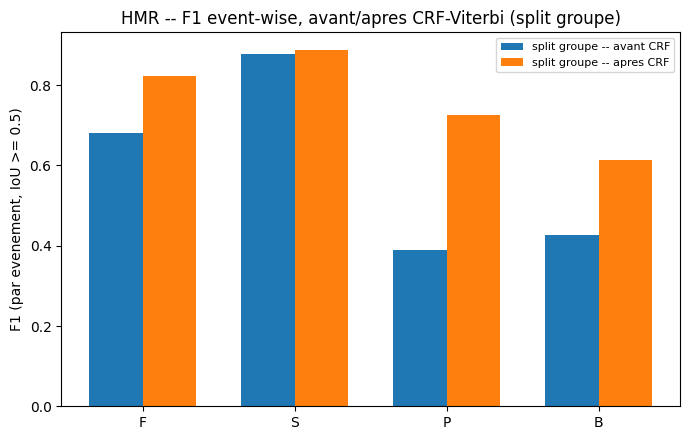

[HMR] Gain macro-F1 apporte par le CRF-Viterbi (split groupe) -- sample-wise: -0.0243 | event-wise: +0.1691


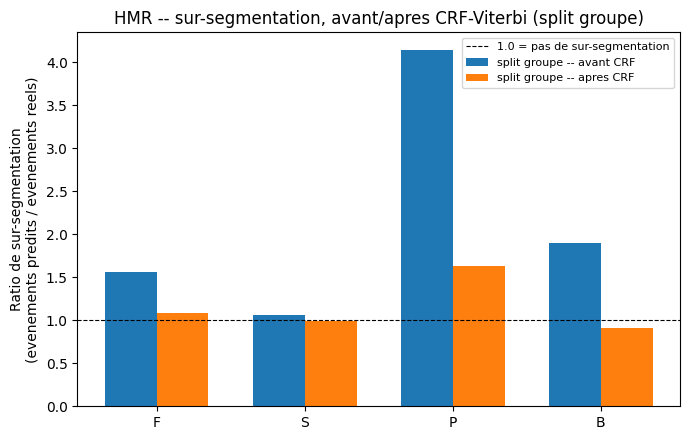

[HMR] Sur-segmentation moyenne (macro, split groupe) -- avant CRF: 2.165 | apres CRF: 1.153 | reduction: +1.012


In [ ]:
delta_sample_hmr, delta_event_hmr = compare_sample_vs_event("HMR", CLASSES_4, result_hmr)
over_before_hmr, over_after_hmr = plot_oversegmentation("HMR", CLASSES_4, result_hmr)

In [ ]:
sample_compare_hmr, event_compare_hmr = recap_table(CLASSES_4, result_hmr)

=== Comparatif sample-wise (precision/recall/F1 par classe + macro_avg) ===


,etape,precision,recall,f1,support
F,split groupe -- avant CRF,0.9585,0.9095,0.9334,71606.0
S,split groupe -- avant CRF,0.7744,0.9070,0.8355,7075.0
P,split groupe -- avant CRF,0.8938,0.9724,0.9314,29758.0
B,split groupe -- avant CRF,0.7686,0.7521,0.7603,8060.0
macro_avg,split groupe -- avant CRF,0.8488,0.8853,0.8651,116499.0
F,split groupe -- apres CRF,0.9675,0.8612,0.9113,71606.0
S,split groupe -- apres CRF,0.6729,0.9454,0.7862,7075.0
P,split groupe -- apres CRF,0.8470,0.9830,0.9099,29758.0
B,split groupe -- apres CRF,0.7459,0.7664,0.7560,8060.0
macro_avg,split groupe -- apres CRF,0.8083,0.8890,0.8408,116499.0



=== Comparatif event-wise (par classe) -- avant/apres CRF, ratio de sur-segmentation inclus ===


,etape,event_precision,event_recall,event_f1,oversegmentation_ratio
class,,,,,
F,split groupe -- avant CRF,0.5576,0.8721,0.6803,1.5640
S,split groupe -- avant CRF,0.8524,0.9054,0.8781,1.0622
P,split groupe -- avant CRF,0.2416,1.0000,0.3891,4.1395
B,split groupe -- avant CRF,0.3258,0.6170,0.4265,1.8936
F,split groupe -- apres CRF,0.7897,0.8585,0.8227,1.0872
S,split groupe -- apres CRF,0.8910,0.8838,0.8874,0.9919
P,split groupe -- apres CRF,0.5857,0.9535,0.7257,1.6279
B,split groupe -- apres CRF,0.6471,0.5851,0.6145,0.9043


In [5]:
table_rtc = build_dataset_table("rtc", iterate_rtc(RTC_ROOT), limit=LIMIT_RTC)
feature_cols_rtc = [c for c in table_rtc.columns if c not in ("label", "group", "recording_id", "subject")]
X_rtc = table_rtc[feature_cols_rtc].to_numpy()
y_rtc = table_rtc["label"].to_numpy()

print(f"\n{len(table_rtc)} echantillons, {len(feature_cols_rtc)} features, "
      f"{table_rtc['recording_id'].nunique()} enregistrements, {table_rtc['group'].nunique()} participants.")
print(table_rtc["label"].value_counts())

  [rtc] PR1_SUT1 (98905 echantillons)
  [rtc] PR1_SUT2 (73966 echantillons)
  [rtc] PR2_SUT1 (123520 echantillons)
  [rtc] PR2_SUT2 (90021 echantillons)
  [rtc] PR3_SUT1 (57135 echantillons)
  [rtc] PR3_SUT2 (72098 echantillons)
  [rtc] PR4_SUT1 (65831 echantillons)
  [rtc] PR4_SUT2 (118062 echantillons)
  4293 echantillon(s) hors ['F', 'S', 'P', 'B'] ecarte(s) (ex: 'noise' RTC).

695245 echantillons, 399 features, 8 enregistrements, 4 participants.
label
F    502648
P     84237
B     57147
S     51213
Name: count, dtype: int64


In [6]:
train_mask_r_rtc, val_mask_r_rtc, test_mask_r_rtc = sample_train_val_test_split(len(table_rtc), seed=RANDOM_STATE)
print(f"Split aleatoire -- train={train_mask_r_rtc.sum()}, val={val_mask_r_rtc.sum()}, test={test_mask_r_rtc.sum()}")

clf_random_rtc = CascadeForestClassifier(
    n_estimators_per_forest=N_ESTIMATORS, max_layers=MAX_LAYERS, random_state=RANDOM_STATE, n_jobs=N_JOBS,
)
clf_random_rtc.fit(X_rtc[train_mask_r_rtc], y_rtc[train_mask_r_rtc], X_rtc[val_mask_r_rtc], y_rtc[val_mask_r_rtc])

sample_report_random_rtc, event_report_random_rtc, y_pred_random_rtc = evaluate_split(
    clf_random_rtc, table_rtc, X_rtc, y_rtc, test_mask_r_rtc, CLASSES_4, "RTC -- SPLIT ALEATOIRE PAR ECHANTILLON",
    show_oversegmentation=False,
)


Split aleatoire -- train=556196, val=69524, test=69525


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 1: val macro-F1 = 0.9125


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 2: val macro-F1 = 0.9703


...

/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== RTC -- SPLIT ALEATOIRE PAR ECHANTILLON -- echantillon par echantillon ===


,precision,recall,f1,support
F,0.9890,0.9922,0.9906,50281.0
S,0.9299,0.9057,0.9177,5143.0
P,0.9897,0.9854,0.9876,8425.0
B,0.9870,0.9884,0.9877,5676.0
macro_avg,0.9739,0.9679,0.9709,69525.0



=== RTC -- SPLIT ALEATOIRE PAR ECHANTILLON -- par evenement ===
(ratio de sur-segmentation non affiche : non interpretable sur un split aleatoire, les sequences temporelles n'y sont pas intactes -- cf. Etape 2 pour ce metrique.)


,n_true_events,n_pred_events,event_precision,event_recall,event_f1
class,,,,,
F,3531,3578,0.9279,0.9402,0.9340
S,3266,3240,0.9306,0.9231,0.9268
P,725,745,0.9597,0.9862,0.9728
B,462,477,0.9497,0.9805,0.9649


In [ ]:
result_rtc = run_group_split_with_crf(
    table_rtc, X_rtc, y_rtc, feature_cols_rtc, CLASSES_4, FS_HZ_RTC,
    n_estimators=N_ESTIMATORS, max_layers=MAX_LAYERS, n_jobs=N_JOBS, random_state=RANDOM_STATE,
)

Split groupe -- train=311770, val=213357, test=170118


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 1: val macro-F1 = 0.7234


/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier w

[CascadeForest] layer 2: val macro-F1 = 0.6287
[CascadeForest] no improvement after layer 2, stopping at 1 layers
[CascadeForest] final model: 1 layers, best val macro-F1 = 0.7234
Durees physiologiques moyennes estimees (ms) : {'F': 451.3841740377719, 'S': 47.08143712574851, 'P': 502.28241563055064, 'B': 655.1903553299492}


...

/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== AVANT CRF-Viterbi (split groupe) -- par evenement ===


,n_true_events,n_pred_events,event_precision,event_recall,event_f1,oversegmentation_ratio
class,,,,,,
F,1427,1978,0.4722,0.6545,0.5486,1.3861
S,1394,1153,0.8647,0.7152,0.7829,0.8271
P,230,753,0.0452,0.1478,0.0692,3.2739
B,130,154,0.7857,0.9308,0.8521,1.1846



=== APRES CRF-Viterbi (split groupe) -- par evenement ===


,n_true_events,n_pred_events,event_precision,event_recall,event_f1,oversegmentation_ratio
class,,,,,,
F,1427,1167,0.7524,0.6153,0.6769,0.8178
S,1394,1125,0.8978,0.7245,0.8019,0.8070
P,230,264,0.3220,0.3696,0.3441,1.1478
B,130,126,0.9841,0.9538,0.9688,0.9692


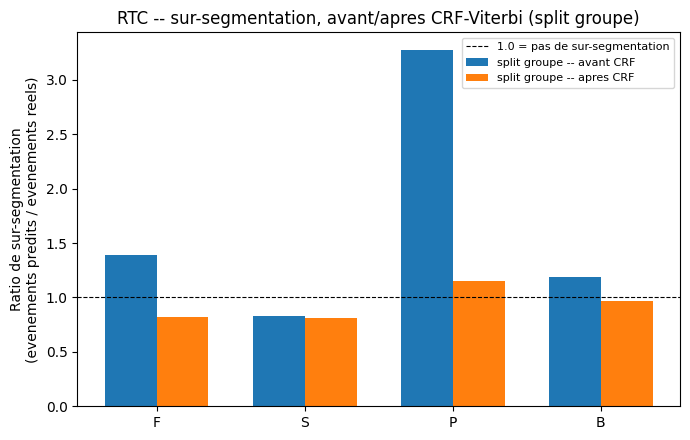

[RTC] Sur-segmentation moyenne (macro, split groupe) -- avant CRF: 1.668 | apres CRF: 0.935 | reduction: +0.732


In [8]:
over_before_rtc, over_after_rtc = plot_oversegmentation("RTC", CLASSES_4, result_rtc)

In [9]:
event_compare_rtc = oversegmentation_table(CLASSES_4, result_rtc)

=== Sur-segmentation par classe -- avant/apres CRF-Viterbi (split groupe) ===


,etape,n_true_events,n_pred_events,oversegmentation_ratio
class,,,,
F,split groupe -- avant CRF,1427,1978,1.3861
S,split groupe -- avant CRF,1394,1153,0.8271
P,split groupe -- avant CRF,230,753,3.2739
B,split groupe -- avant CRF,130,154,1.1846
F,split groupe -- apres CRF,1427,1167,0.8178
S,split groupe -- apres CRF,1394,1125,0.8070
P,split groupe -- apres CRF,230,264,1.1478
B,split groupe -- apres CRF,130,126,0.9692


In [ ]:
# === Imports Stage 2 (cf. eye_movement_classification_clean-2.ipynb, cellules 2 et 4) ===
import glob
import json
from time import perf_counter
from contextlib import contextmanager

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import (
    classification_report, accuracy_score, precision_recall_curve,
    precision_recall_fscore_support,
)

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

tf.get_logger().setLevel("ERROR")


In [ ]:
# === Configuration Stage 2 (cf. notebook de reference, cellule 7) ===
# Reprise a l'identique, seuls "data_folder" et "output_dir" sont adaptes aux
# chemins locaux deja resolus en Stage 1 (PUPIL_ROOT / RTC_ROOT / CACHE_ROOT)
# au lieu des chemins Google Drive/Colab du notebook de reference.
CONFIG_STAGE2 = {
    # --- Donnees ---
    "data_folder": str(RTC_ROOT),           # dossier contenant les CSV RTC annotes
    "file_pattern": "*.csv",
    "label_column": "classification_Kmeans",
    "fs": FS_HZ_RTC,                        # 200.0 Hz, deja defini en Stage 1
    "seed": RANDOM_STATE,

    # --- Stage 2 : fenetrage glissant ---
    "stage2_window": 20,                    # meilleure config du notebook de reference (stride=1)
    "stage2_stride": 1,
    "stage2_epochs_cv": 5 if QUICK else 60,     # QUICK=True (deja defini en Stage 1) : run rapide
    "stage2_epochs_final": 5 if QUICK else 60,  # False = run complet de reference (60 epochs, comme l'original)
    "stage2_batch_size": 32,

    # --- Stage 2 : Hard Negative Mining + Focal Loss ---
    "hnm_augmentation_factor": 5,
    "hnm_initial_ratio": 5,
    "hnm_remine_every": 3,
    "focal_gamma": 3.0,
    "focal_alpha": 0.95,

    # --- Sortie ---
    "output_dir": str(PUPIL_ROOT / "results" / "stage2_rtc"),
}

CLASS_MAPPING_STAGE2 = {"fixation": 0, "saccade": 1, "smooth_pursuit": 2, "blink": 3, "microsaccade": 4}
REVERSE_MAPPING_STAGE2 = {v: k for k, v in CLASS_MAPPING_STAGE2.items()}

tf.keras.utils.set_random_seed(CONFIG_STAGE2["seed"])


@contextmanager
def timeit(label: str):
    """Petit utilitaire de chronometrage (cf. notebook de reference, cellule 7)."""
    t0 = perf_counter()
    try:
        yield
    finally:
        print(f"[OK] {label} : {perf_counter() - t0:.3f}s")


print(f"CONFIG_STAGE2 = {CONFIG_STAGE2}")


CONFIG_STAGE2 = {'data_folder': '/content/drive/MyDrive/HEMC_model/Data/data_RTC', 'file_pattern': '*.csv', 'label_column': 'classification_Kmeans', 'fs': 200.0, 'seed': 42, 'stage2_window': 20, 'stage2_stride': 1, 'stage2_epochs_cv': 5, 'stage2_epochs_final': 5, 'stage2_batch_size': 32, 'hnm_augmentation_factor': 5, 'hnm_initial_ratio': 5, 'hnm_remine_every': 3, 'focal_gamma': 3.0, 'focal_alpha': 0.95, 'output_dir': '/content/drive/MyDrive/HEMC_model/results/stage2_rtc'}


In [ ]:
def load_data_from_folder(folder_path, file_pattern, label_column, fs, class_mapping):
    '''Charge tous les CSV d'un dossier, nettoie et normalise les labels.'''
    print(f"Chargement depuis : {folder_path} | pattern : {file_pattern}")
    required_columns = ["gaze x [px]", "gaze y [px]", label_column]

    csv_files = glob.glob(os.path.join(folder_path, file_pattern))
    if not csv_files:
        raise FileNotFoundError(f"Aucun fichier trouvé pour le pattern : {file_pattern}")

    label_aliases = {
        "f": "fixation", "fix": "fixation", "fixations": "fixation",
        "s": "saccade", "saccades": "saccade",
        "p": "smooth_pursuit", "sp": "smooth_pursuit", "pursuit": "smooth_pursuit",
        "b": "blink", "clignement": "blink",
        "micro": "microsaccade", "microsaccades": "microsaccade", "µs": "microsaccade",
        "micro saccade": "microsaccade", "micro-saccade": "microsaccade",
        "microsacade": "microsaccade", "ms": "microsaccade",
    }

    all_dfs, file_info = [], []
    with timeit("Chargement + nettoyage des CSV"):
        for fid, fp in enumerate(csv_files):
            df = pd.read_csv(fp)
            df = df.dropna(subset=required_columns).copy()
            df[label_column] = df[label_column].astype(str).str.strip().str.lower()
            df[label_column] = df[label_column].replace(label_aliases)
            df = df[df[label_column].isin(class_mapping.keys())].copy()

            dx = np.diff(df["gaze x [px]"], prepend=df["gaze x [px]"].iloc[0]) * fs
            dy = np.diff(df["gaze y [px]"], prepend=df["gaze y [px]"].iloc[0]) * fs
            df["velocity"] = np.sqrt(dx ** 2 + dy ** 2)
            df["file_source"] = os.path.basename(fp)
            df["file_id"] = fid

            file_info.append({
                "filename": os.path.basename(fp),
                "samples": len(df),
                "class_counts": df[label_column].value_counts().to_dict(),
            })
            all_dfs.append(df)

        data = pd.concat(all_dfs, ignore_index=True)
        print(f"Total : {len(data):,} lignes sur {len(all_dfs)} fichiers")
        print(data[label_column].value_counts())
    return data, file_info


In [ ]:
# Exécution (cf. notebook de reference, cellule 9) -- adapte pour ne charger que RTC,
# via CONFIG_STAGE2["data_folder"] = RTC_ROOT (defini en Stage 1 ci-dessus).
data_stage2_rtc, file_info_stage2_rtc = load_data_from_folder(
    CONFIG_STAGE2["data_folder"], CONFIG_STAGE2["file_pattern"], CONFIG_STAGE2["label_column"],
    CONFIG_STAGE2["fs"], CLASS_MAPPING_STAGE2,
)


Chargement depuis : /content/drive/MyDrive/HEMC_model/Data/data_RTC | pattern : *.csv
Total : 1,088,865 lignes sur 14 fichiers
classification_Kmeans
fixation          791269
smooth_pursuit    136886
blink              73479
saccade            67650
microsaccade       19581
Name: count, dtype: int64
[OK] Chargement + nettoyage des CSV : 28.483s


In [ ]:
def preprocess_sliding_window(data, label_column, window, stride, fs):
    '''Construit les fenêtres glissantes Stage 2 (fixation vs microsaccade).'''
    half = window // 2
    segments, labels, sources = [], [], []
    n_ms, n_fix = 0, 0

    for fid in data["file_id"].unique():
        sub = data[data["file_id"] == fid].reset_index(drop=True)
        x = sub["gaze x [px]"].values.astype(np.float32)
        y = sub["gaze y [px]"].values.astype(np.float32)
        v = sub["velocity"].values.astype(np.float32)
        lbl = sub[label_column].values
        fname = sub["file_source"].iloc[0]
        n = len(sub)

        for center in range(half, n - half, stride):
            s, e = center - half, center + half
            if e > n:
                break
            center_label = lbl[center]
            if center_label not in ("microsaccade", "fixation"):
                continue
            segments.append(np.column_stack([x[s:e], y[s:e], v[s:e]]))
            labels.append(center_label)
            sources.append(fname)
            n_ms += center_label == "microsaccade"
            n_fix += center_label == "fixation"

    def to_6_channels(seg):
        x, y, _v = seg[:, 0], seg[:, 1], seg[:, 2]
        vx, vy = np.gradient(x) * fs, np.gradient(y) * fs
        speed = np.hypot(vx, vy)
        acc = np.gradient(speed) * fs
        return np.column_stack([x, y, vx, vy, speed, np.abs(acc)]).astype(np.float32)

    X = np.array([to_6_channels(s) for s in segments], dtype=np.float32) if segments else np.empty((0,))
    y = np.array(labels, dtype=object)
    groups = np.array(sources, dtype=object)

    print(f"Fenêtres Stage 2 : {len(X)} | MS : {n_ms} | Fixations : {n_fix} | ratio : {n_ms/max(n_fix,1):.3f}")
    return X, y, groups


In [ ]:
def augment_time_series(X, jitter_std=0.3, shift_max=1, stretch_low=0.95, stretch_high=1.05,
                        p=0.8, seed=42):
    '''Augmentation de séries temporelles (jitter, décalage, étirement) pour les fenêtres MS.'''
    rng = np.random.default_rng(seed)
    X_aug = X.copy()
    n, L, C = X.shape
    for i in range(n):
        if rng.random() < p:
            X_aug[i] += rng.normal(0, jitter_std, size=(L, C))
        if rng.random() < p:
            k = int(rng.integers(-shift_max, shift_max + 1))
            if k > 0:
                X_aug[i, k:, :] = X_aug[i, :-k, :]; X_aug[i, :k, :] = 0
            elif k < 0:
                k = -k
                X_aug[i, :-k, :] = X_aug[i, k:, :]; X_aug[i, -k:, :] = 0
        if rng.random() < p:
            s = float(rng.uniform(stretch_low, stretch_high))
            newL = int(round(L * s))
            idx = np.linspace(0, L - 1, newL)
            Xr = np.stack([np.interp(idx, np.arange(L), X_aug[i, :, c]) for c in range(C)], axis=1)
            if newL >= L:
                X_aug[i] = Xr[:L]
            else:
                pad = np.zeros((L, C), dtype=X.dtype); pad[:newL] = Xr; X_aug[i] = pad
    return X_aug


def prepare_hnm_dataset(X, y, groups, augmentation_factor=5, initial_ratio=5, seed=42):
    '''Augmente les micro-saccades et construit le dataset initial (ratio 1:initial_ratio),
    en conservant un pool complet de fixations pour le mining ultérieur.'''
    rng = np.random.default_rng(seed)
    ms_mask = y == 1
    X_ms, y_ms, groups_ms = X[ms_mask], y[ms_mask], groups[ms_mask]
    X_fix, y_fix, groups_fix = X[~ms_mask], y[~ms_mask], groups[~ms_mask]

    X_ms_list, y_ms_list, groups_ms_list = [X_ms], [y_ms], [groups_ms]
    for i in range(augmentation_factor - 1):
        X_ms_list.append(augment_time_series(X_ms, seed=seed + i))
        y_ms_list.append(y_ms.copy())
        groups_ms_list.append(groups_ms.copy())
    X_ms_aug = np.concatenate(X_ms_list)
    y_ms_aug = np.concatenate(y_ms_list)
    groups_ms_aug = np.concatenate(groups_ms_list)

    n_fix_init = min(len(X_ms_aug) * initial_ratio, len(X_fix))
    fix_idx = rng.choice(len(X_fix), size=n_fix_init, replace=False)

    X_init = np.concatenate([X_ms_aug, X_fix[fix_idx]])
    y_init = np.concatenate([y_ms_aug, y_fix[fix_idx]])
    groups_init = np.concatenate([groups_ms_aug, groups_fix[fix_idx]])

    shuffle = rng.permutation(len(X_init))
    X_init, y_init, groups_init = X_init[shuffle], y_init[shuffle], groups_init[shuffle]

    return {
        "X_init": X_init, "y_init": y_init, "groups_init": groups_init,
        "X_ms_augmented": X_ms_aug, "y_ms_augmented": y_ms_aug,
        "X_fix_pool": X_fix, "y_fix_pool": y_fix,
    }


def focal_loss(gamma=3.0, alpha=0.95):
    '''Focal loss binaire, pour concentrer l'apprentissage sur la classe minoritaire (MS).'''
    def _fl(y_true, y_pred):
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1. - eps)
        pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1. - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha, 1. - alpha)
        return -tf.reduce_mean(alpha_t * tf.pow(1. - pt, gamma) * tf.math.log(pt))
    return _fl


class ProgressiveHardNegativeMining(tf.keras.callbacks.Callback):
    '''Callback Keras : ré-échantillonne périodiquement les négatifs (fixations) en
    privilégiant les plus ambigus, selon un curriculum en 3 phases.'''

    def __init__(self, X_pool_ms, X_pool_fix, y_pool_ms, y_pool_fix,
                 initial_ratio=5, remine_every=3, verbose=1):
        super().__init__()
        self.X_ms, self.y_ms = X_pool_ms, y_pool_ms
        self.X_fix_pool, self.y_fix_pool = X_pool_fix, y_pool_fix
        self.initial_ratio = initial_ratio
        self.remine_every = remine_every
        self.verbose = verbose
        self.fix_difficulty_scores = np.zeros(len(X_pool_fix))
        self.mining_history = []

    def _get_mining_strategy(self, epoch):
        if epoch < 15:
            return {"hard_ratio": 0.5, "phase": "Warm-up"}
        elif epoch < 40:
            return {"hard_ratio": 0.7, "phase": "Focus"}
        return {"hard_ratio": 0.8, "phase": "Fine-tune"}

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.remine_every != 0:
            return
        strategy = self._get_mining_strategy(epoch)
        scores = self.model.predict(self.X_fix_pool, verbose=0).ravel()
        alpha = 0.7
        self.fix_difficulty_scores = alpha * scores + (1 - alpha) * self.fix_difficulty_scores

        n_total = len(self.X_ms) * self.initial_ratio
        n_hard = int(n_total * strategy["hard_ratio"])
        n_easy = n_total - n_hard
        hard_idx = np.argsort(self.fix_difficulty_scores)[-n_hard:]
        easy_idx = np.argsort(scores)[:n_easy]

        self.mining_history.append({
            "epoch": epoch + 1, "phase": strategy["phase"],
            "n_hard": len(hard_idx), "n_easy": len(easy_idx),
            "hard_score_mean": float(scores[hard_idx].mean()),
            "easy_score_mean": float(scores[easy_idx].mean()),
        })
        if self.verbose:
            print(f"  Mining epoch {epoch+1} [{strategy['phase']}] "
                  f"Hard: {len(hard_idx)} ({scores[hard_idx].mean():.3f}) "
                  f"Easy: {len(easy_idx)} ({scores[easy_idx].mean():.3f})")


def build_stage2_resnet1d(win, n_ch, focal_gamma, focal_alpha, seed=42):
    '''ResNet1D à 3 blocs résiduels dilatés (dilation 1/2/4) + tête de classification binaire.'''
    tf.keras.utils.set_random_seed(seed)
    inp = layers.Input((win, n_ch))

    def residual_block(x, filters, kernel=3, dilation=1):
        y = layers.Conv1D(filters, kernel, padding="same", dilation_rate=dilation)(x)
        y = layers.BatchNormalization()(y)
        y = layers.ReLU()(y)
        y = layers.Conv1D(filters, kernel, padding="same", dilation_rate=dilation)(y)
        y = layers.BatchNormalization()(y)
        if x.shape[-1] != filters:
            x = layers.Conv1D(filters, 1, padding="same")(x)
        return layers.ReLU()(layers.add([x, y]))

    x = residual_block(inp, 32, kernel=5, dilation=1)
    x = residual_block(x, 64, kernel=3, dilation=2)
    x = residual_block(x, 128, kernel=3, dilation=4)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(optimizer="adam", loss=focal_loss(focal_gamma, focal_alpha), metrics=["accuracy"])
    return model


In [ ]:
def train_stage2_hnm(X, y_raw, groups, config):
    '''Entraîne le ResNet1D + HNM en LOSO (GroupKFold sur fichiers/sujets), puis modèle final.'''
    print("="*70, "\nSTAGE 2 — ResNet1D + Hard Negative Mining (LOSO)\n" + "="*70)
    y = np.array([1 if l == "microsaccade" else 0 for l in y_raw], dtype=int)

    hnm_data = prepare_hnm_dataset(X, y, groups,
                                    augmentation_factor=config["hnm_augmentation_factor"],
                                    initial_ratio=config["hnm_initial_ratio"], seed=config["seed"])
    X_init, y_init, groups_init = hnm_data["X_init"], hnm_data["y_init"], hnm_data["groups_init"]
    X_ms_aug, y_ms_aug = hnm_data["X_ms_augmented"], hnm_data["y_ms_augmented"]
    X_fix_pool, y_fix_pool = hnm_data["X_fix_pool"], hnm_data["y_fix_pool"]

    gkf = GroupKFold(n_splits=len(np.unique(groups_init)))
    accs, f1s, precs, recs, thr_list = [], [], [], [], []
    y_true_all, y_pred_all, y_scores_all = [], [], []

    for fold, (tr, te) in enumerate(gkf.split(X_init, y_init, groups=groups_init)):
        Xtr, Xte, ytr, yte = X_init[tr], X_init[te], y_init[tr], y_init[te]
        mu, sd = Xtr.mean(axis=(0, 1)), Xtr.std(axis=(0, 1)); sd[sd < 1e-8] = 1.0
        Xtr_n, Xte_n = (Xtr - mu) / sd, (Xte - mu) / sd
        X_ms_n, X_fix_n = (X_ms_aug - mu) / sd, (X_fix_pool - mu) / sd

        model = build_stage2_resnet1d(X_init.shape[1], X_init.shape[2],
                                      config["focal_gamma"], config["focal_alpha"],
                                      seed=config["seed"] + fold)
        callbacks = [
            EarlyStopping(patience=10, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(factor=0.5, patience=5, verbose=0),
            ProgressiveHardNegativeMining(X_ms_n, X_fix_n, y_ms_aug, y_fix_pool,
                                          initial_ratio=config["hnm_initial_ratio"],
                                          remine_every=config["hnm_remine_every"], verbose=0),
        ]
        model.fit(Xtr_n, ytr, validation_data=(Xte_n, yte), epochs=config["stage2_epochs_cv"],
                  batch_size=config["stage2_batch_size"], callbacks=callbacks, verbose=0)

        scores = model.predict(Xte_n, verbose=0).ravel()
        P, R, T = precision_recall_curve(yte, scores)
        F1 = 2 * P * R / (P + R + 1e-12)
        thr = T[np.argmax(F1)] if len(T) > 0 else 0.5
        yp = (scores >= thr).astype(int)

        prec, rec, f1, _ = precision_recall_fscore_support(yte, yp, labels=[1], average="binary", zero_division=0)
        accs.append(accuracy_score(yte, yp)); f1s.append(f1); precs.append(prec); recs.append(rec)
        thr_list.append(float(thr))
        y_true_all.extend(yte.tolist()); y_pred_all.extend(yp.tolist()); y_scores_all.extend(scores.tolist())
        print(f"  Fold {fold+1} — F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | Thr: {thr:.3f}")

    best_threshold = float(np.mean(thr_list))
    print(f"\nLOSO — F1: {np.mean(f1s):.4f} ± {np.std(f1s):.4f} | "
          f"Precision: {np.mean(precs):.4f} | Recall: {np.mean(recs):.4f} | "
          f"Accuracy: {np.mean(accs):.4f} | Seuil optimal: {best_threshold:.3f}")
    print(classification_report(y_true_all, y_pred_all, target_names=["Fixation", "Microsaccade"], zero_division=0))

    # Modèle final sur l'ensemble des données
    mu, sd = X_init.mean(axis=(0, 1)), X_init.std(axis=(0, 1)); sd[sd < 1e-8] = 1.0
    Xn = (X_init - mu) / sd
    X_ms_n, X_fix_n = (X_ms_aug - mu) / sd, (X_fix_pool - mu) / sd
    final_model = build_stage2_resnet1d(X_init.shape[1], X_init.shape[2],
                                        config["focal_gamma"], config["focal_alpha"], seed=config["seed"])
    final_model.fit(Xn, y_init, epochs=config["stage2_epochs_final"], batch_size=config["stage2_batch_size"],
                     callbacks=[ProgressiveHardNegativeMining(X_ms_n, X_fix_n, y_ms_aug, y_fix_pool,
                                initial_ratio=config["hnm_initial_ratio"],
                                remine_every=config["hnm_remine_every"], verbose=0)], verbose=0)

    results = {
        "accuracy": float(np.mean(accs)), "f1_score": float(np.mean(f1s)), "f1_std": float(np.std(f1s)),
        "precision": float(np.mean(precs)), "recall": float(np.mean(recs)), "best_threshold": best_threshold,
        "y_true_loso": y_true_all, "y_pred_loso": y_pred_all, "y_scores_loso": y_scores_all,
    }
    norm_stats = {"mu": mu.astype(np.float32), "sd": sd.astype(np.float32)}
    return final_model, norm_stats, results


In [ ]:
def save_stage2_pipeline(output_dir, config, stage2_model, stage2_norm_stats):
    """Serialise les artefacts Stage 2 (adapte de `save_pipeline`, notebook de reference,
    cellule 21 -- ici sans les artefacts Stage 1/HMM, non entraines dans ce notebook)."""
    p = Path(output_dir); p.mkdir(parents=True, exist_ok=True)
    (p / "config_stage2.json").write_text(json.dumps(config, indent=2, default=str))
    stage2_model.save(str(p / "stage2_resnet1d_hnm.keras"))
    np.savez(p / "stage2_norm_stats.npz", mu=stage2_norm_stats["mu"], sd=stage2_norm_stats["sd"])
    print(f"Pipeline Stage 2 sauvegarde dans : {p.resolve()}")


In [ ]:
X2_rtc, y2_raw_rtc, groups2_rtc = preprocess_sliding_window(
    data_stage2_rtc, CONFIG_STAGE2["label_column"], CONFIG_STAGE2["stage2_window"],
    CONFIG_STAGE2["stage2_stride"], CONFIG_STAGE2["fs"],
)

stage2_model_rtc, stage2_norm_stats_rtc, stage2_results_rtc = train_stage2_hnm(
    X2_rtc, y2_raw_rtc, groups2_rtc, CONFIG_STAGE2,
)

save_stage2_pipeline(CONFIG_STAGE2["output_dir"], CONFIG_STAGE2, stage2_model_rtc, stage2_norm_stats_rtc)


Fenêtres Stage 2 : 810668 | MS : 19580 | Fixations : 791088 | ratio : 0.025
STAGE 2 — ResNet1D + Hard Negative Mining (LOSO)
  Fold 1 — F1: 0.8492 | Prec: 0.9243 | Rec: 0.7853 | Thr: 0.600
  Fold 2 — F1: 0.8101 | Prec: 0.8544 | Rec: 0.7701 | Thr: 0.702
  Fold 3 — F1: 0.8483 | Prec: 0.9159 | Rec: 0.7900 | Thr: 0.567
  Fold 4 — F1: 0.7133 | Prec: 0.8047 | Rec: 0.6405 | Thr: 0.678
  Fold 5 — F1: 0.8988 | Prec: 0.9099 | Rec: 0.8880 | Thr: 0.700
  Fold 6 — F1: 0.8756 | Prec: 0.9227 | Rec: 0.8330 | Thr: 0.637
  Fold 7 — F1: 0.6681 | Prec: 0.9004 | Rec: 0.5311 | Thr: 0.852
  Fold 8 — F1: 0.8378 | Prec: 0.8998 | Rec: 0.7838 | Thr: 0.601
  Fold 9 — F1: 0.6614 | Prec: 0.9825 | Rec: 0.4985 | Thr: 0.832
  Fold 10 — F1: 0.9200 | Prec: 0.9227 | Rec: 0.9172 | Thr: 0.629
  Fold 11 — F1: 0.8743 | Prec: 0.9332 | Rec: 0.8225 | Thr: 0.709
  Fold 12 — F1: 0.8928 | Prec: 0.9380 | Rec: 0.8517 | Thr: 0.652
  Fold 13 — F1: 0.9099 | Prec: 0.9222 | Rec: 0.8979 | Thr: 0.694
  Fold 14 — F1: 0.7892 | Prec: 0.8772 |